In [10]:
# Cell 0: Imports and display settings

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

print("Ready")

Ready


cols: ['Topic', 'Count', 'Name', 'Representation', 'Representative_Docs']


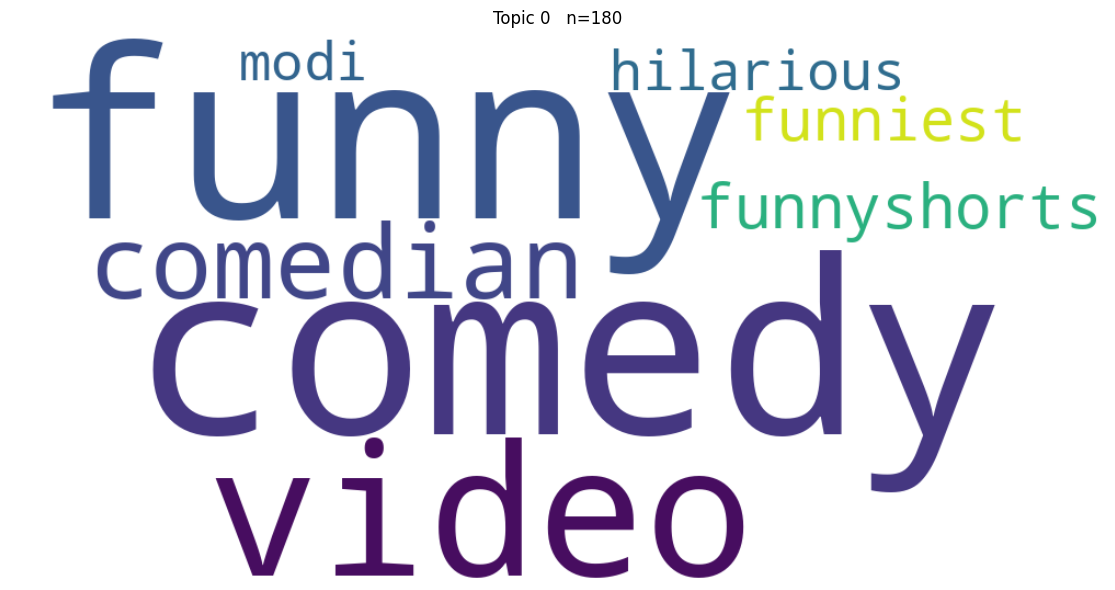

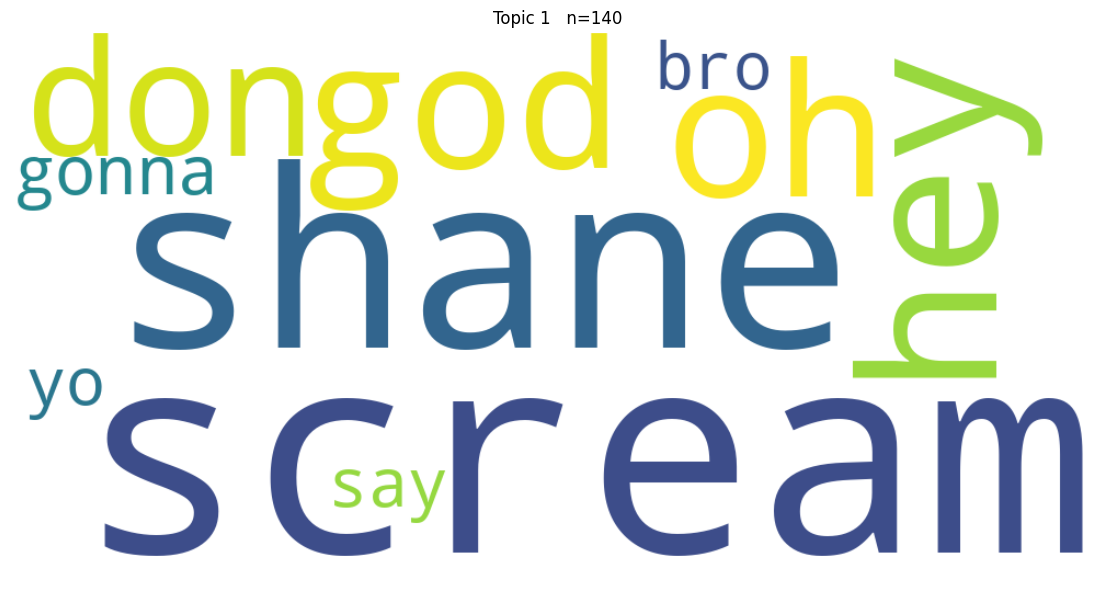

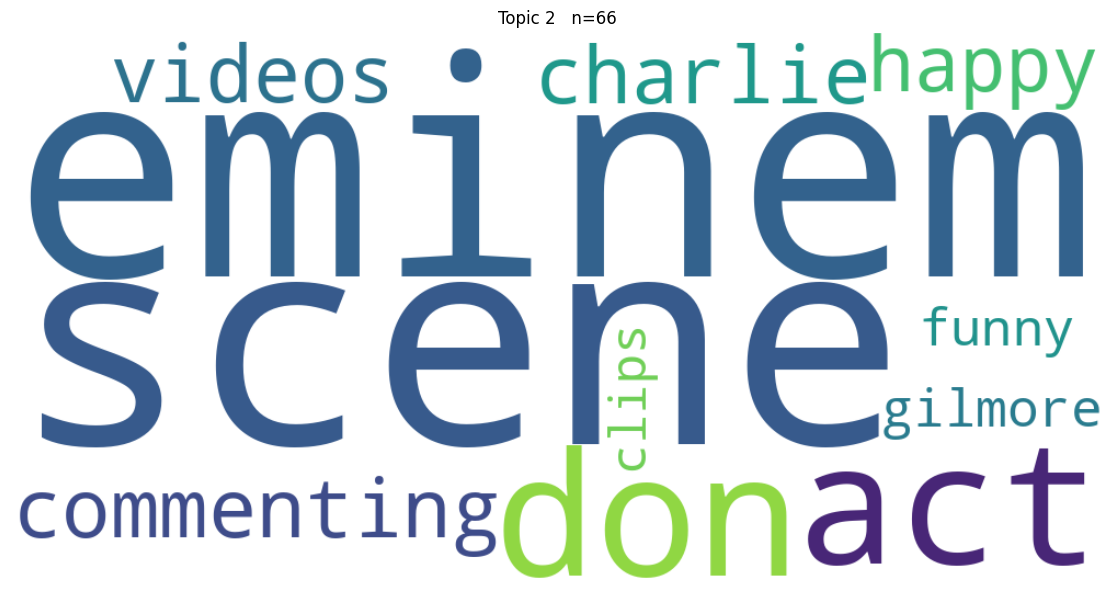

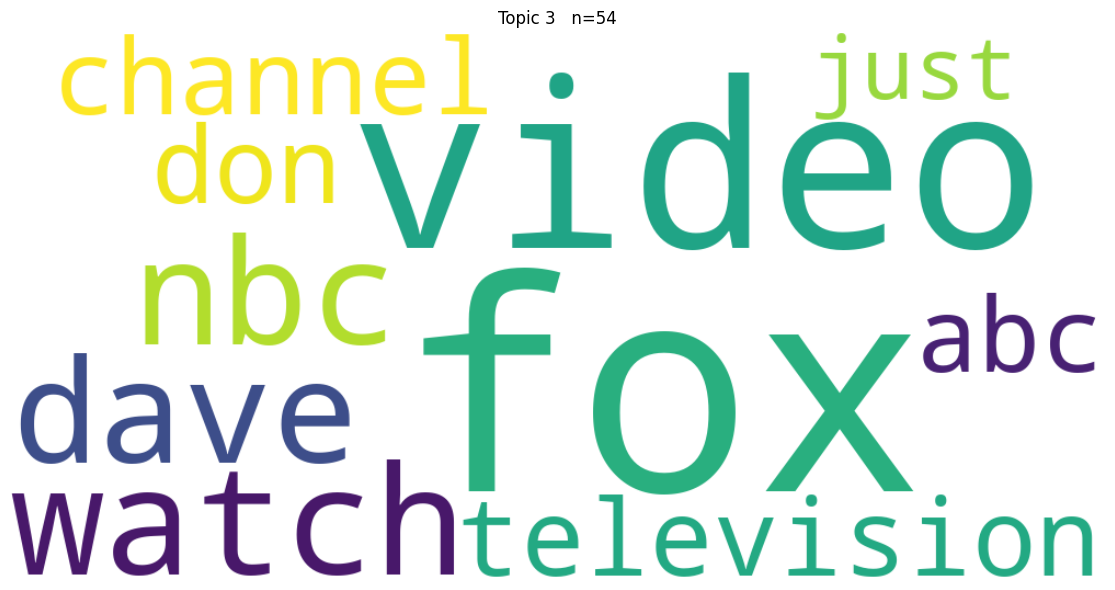

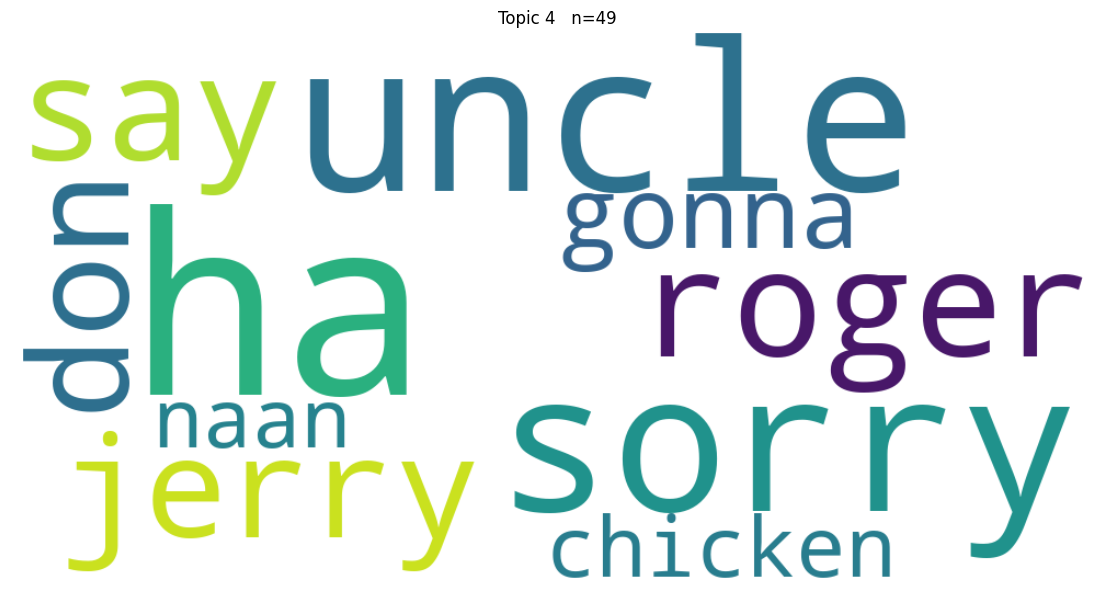

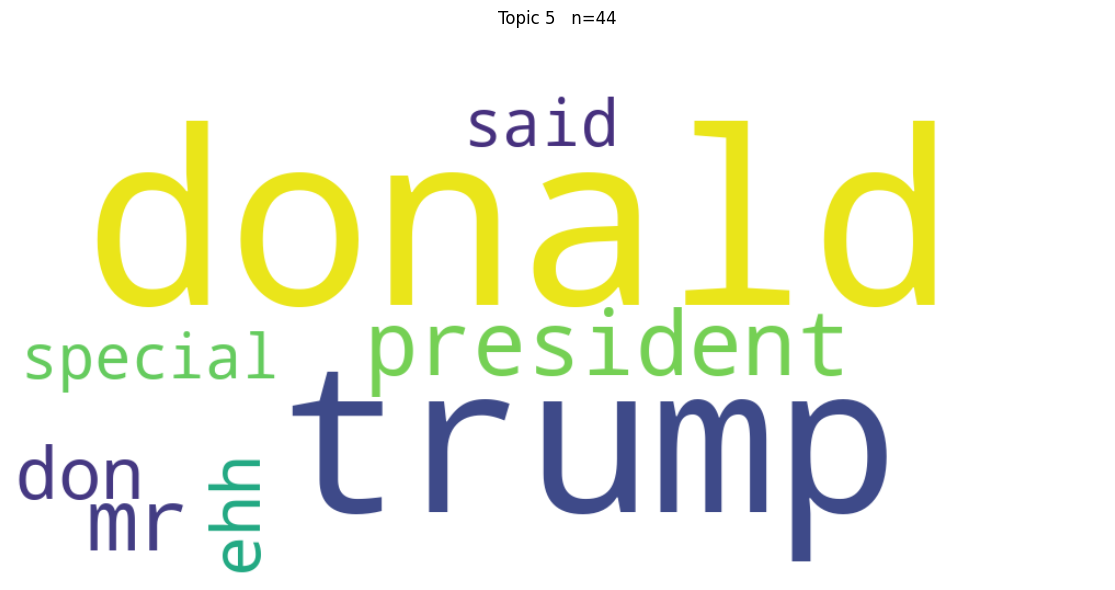

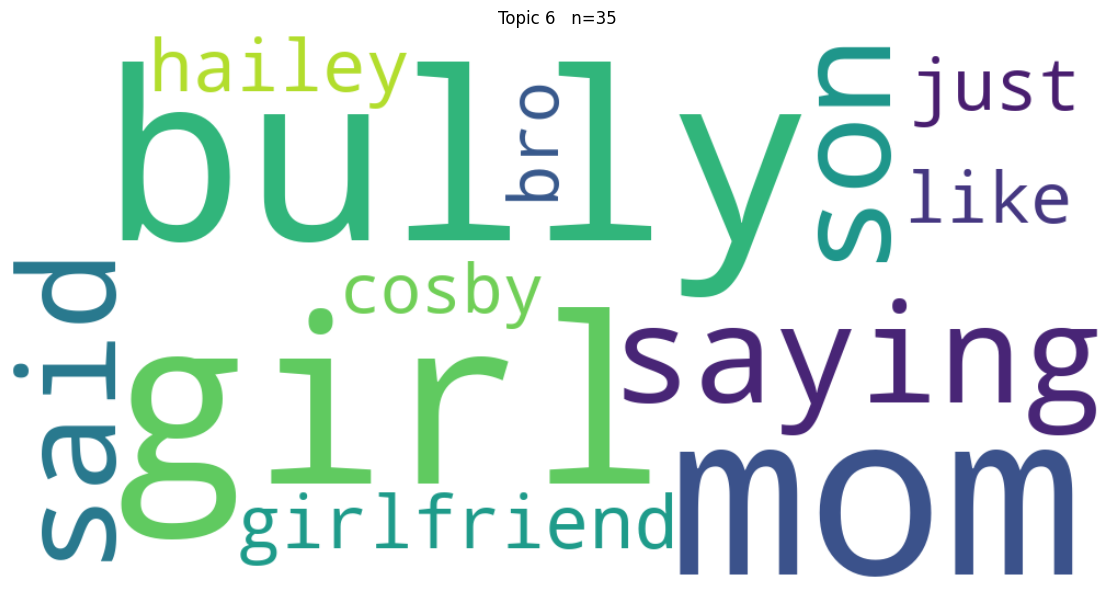

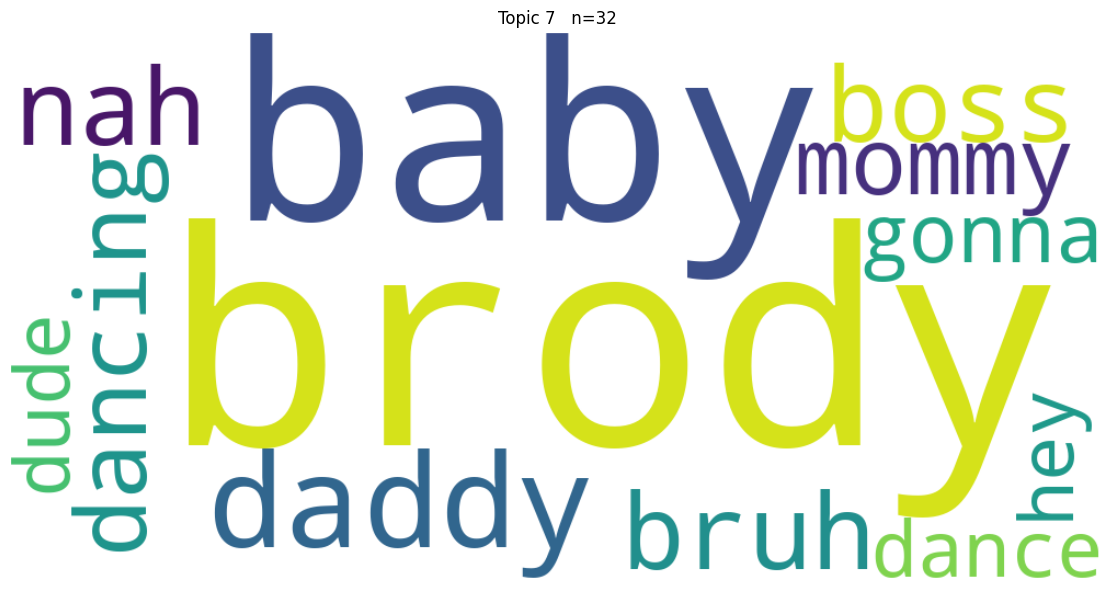

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re

TOPIC_INFO_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"

topic_info = pd.read_csv(TOPIC_INFO_PATH)
print("cols:", list(topic_info.columns))

def extract_words_and_weights(row, top_n=40):
    # Most common BERTopic exports include one of these columns
    text = None
    for c in ["Representation", "Top_n_words", "Words", "Name"]:
        if c in row and pd.notna(row[c]):
            text = str(row[c])
            break

    if text is None:
        return {}

    # Try to parse formats like:
    # "word1, word2, word3"
    # or "['word1', 'word2']"
    # or "word1_word2_word3"
    text = text.replace("_", " ")
    text = re.sub(r"[\[\]\(\)\{\}\'\"]", " ", text)
    parts = re.split(r"[,\s]+", text)
    parts = [p.strip() for p in parts if p.strip()]

    # Make simple frequency weights that decay
    freqs = {}
    for i, w in enumerate(parts[:top_n]):
        # higher weight for earlier words
        freqs[w] = freqs.get(w, 0) + (top_n - i)
    return freqs

# keep real topics only
if "Topic" in topic_info.columns:
    wc_df = topic_info[topic_info["Topic"] != -1].copy()
else:
    wc_df = topic_info.copy()

# pick top N topics by Count if present
TOP_N_TOPICS = 8
if "Count" in wc_df.columns:
    wc_df = wc_df.sort_values("Count", ascending=False).head(TOP_N_TOPICS)
else:
    wc_df = wc_df.head(TOP_N_TOPICS)

for _, row in wc_df.iterrows():
    topic_id = row["Topic"] if "Topic" in wc_df.columns else "NA"
    count = row["Count"] if "Count" in wc_df.columns else None

    freqs = extract_words_and_weights(row, top_n=40)
    if not freqs:
        continue

    wc = WordCloud(width=1000, height=500, background_color="white").generate_from_frequencies(freqs)

    plt.figure(figsize=(12, 6))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    title = f"Topic {topic_id}"
    if count is not None:
        title += f"   n={int(count)}"
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [ ]:
# Cell 0: Load files

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

TOPICS_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/bertopic_topics.csv"
TOPIC_INFO_PATH = "/home/kiwi-pandas/Documents/humor-harm-api/scripts/topic_analysis/topic_analysis_bertopic_topic_info.csv"

topics_df = pd.read_csv(TOPICS_PATH)
topic_info = pd.read_csv(TOPIC_INFO_PATH)

print("topics_df", topics_df.shape)
print("topic_info", topic_info.shape)

topics_df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/home/kiwi-pandas/Documents/humor-harm-api/scripts/topics_analysis/topic_analysis_bertopic_topic_info.csv'

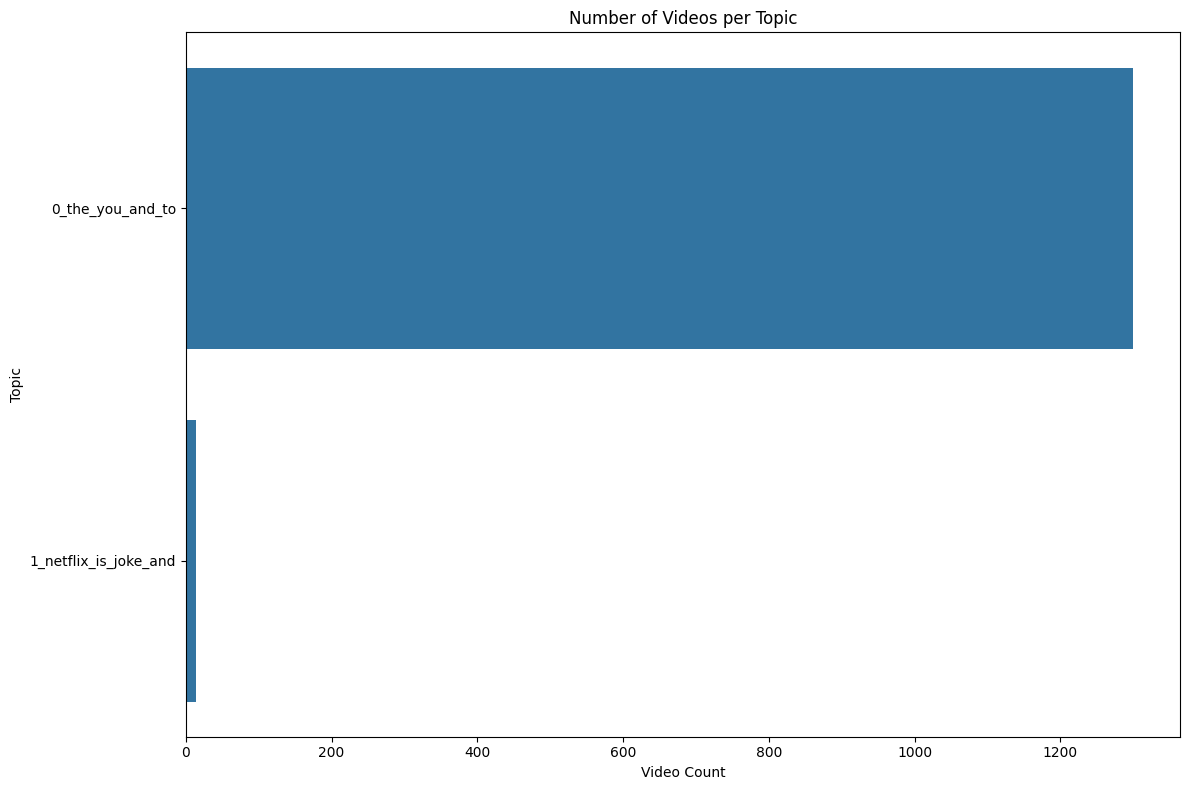

,topic_name,video_count
0,0_the_you_and_to,1299
1,1_netflix_is_joke_and,14


In [4]:
# Cell 3: Topic distribution (bar plot)

topic_counts = topics_df["topic_name"].value_counts().reset_index()
topic_counts.columns = ["topic_name", "video_count"]

plt.figure(figsize=(12, 8))
sns.barplot(data=topic_counts, x="video_count", y="topic_name")
plt.title("Number of Videos per Topic")
plt.xlabel("Video Count")
plt.ylabel("Topic")
plt.tight_layout()
plt.show()

topic_counts.head(15)